# Técnicas usada para o aumento de contraste padrão
As técnicas são:
* Transformações Logaritímicas e de Potência
* Equalização de Histograma
* Equalização de Histograma 

## obs: importações

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## Transformação Logaritimica

Exibindo imagem original de baixo contraste...
Exibindo e comparando o resultado...


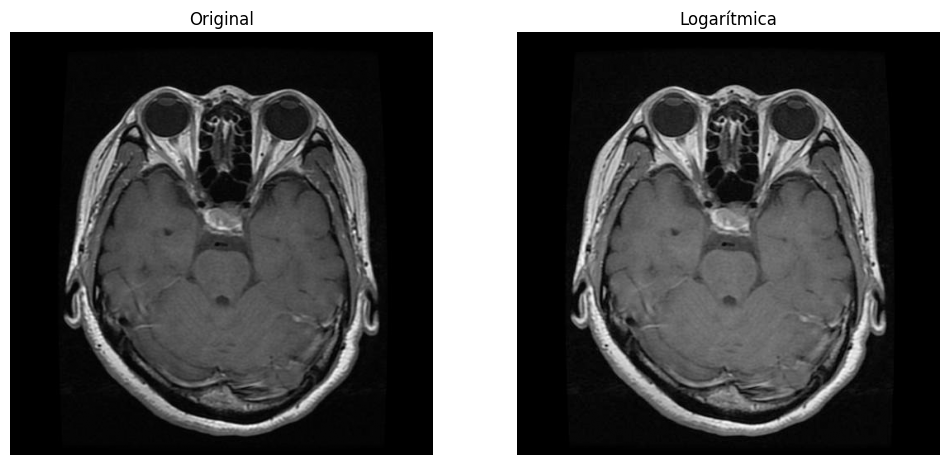

In [4]:
# --- 2. Carregamento da imagem ---
caminho_da_imagem = "P_1.jpg"
img_baixo_contraste = cv2.imread(caminho_da_imagem, cv2.IMREAD_GRAYSCALE)

print("Exibindo imagem original de baixo contraste...")

# Normaliza a imagem para 0-1 igual ao EBImage
img_norm = img_baixo_contraste / 255.0

# --- 3. Aplicação da Transformação Logarítmica ---
img_log_transformada = np.log(1 + img_norm)

# Normalização final para 0-1
img_log_final = cv2.normalize(img_log_transformada, None, 0, 1, cv2.NORM_MINMAX)

# --- 4. Exibição e Comparação ---
print("Exibindo e comparando o resultado...")

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_baixo_contraste, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_log_final, cmap='gray')
plt.title("Logarítmica")
plt.axis("off")

plt.show()

## Transformação de Potência

Exibindo imagem original de baixo contraste...
Exibindo e comparando o resultado com Gamma = 0.5...


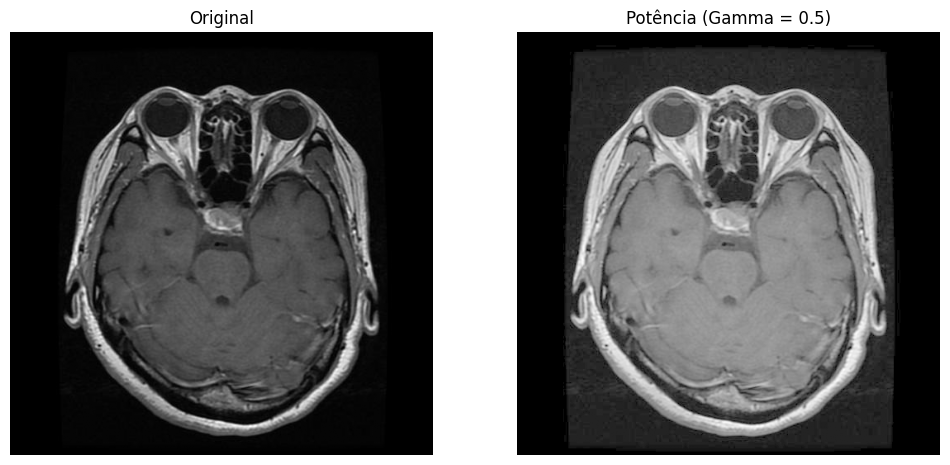

In [5]:
# --- 2. Parâmetro Gamma ---
# Para REALÇAR SOMBRAS (clarear áreas escuras), use gamma < 1
GAMMA_VALUE = 0.5

# Para ESCURECER AS SOMBRAS (realçar áreas claras), use gamma > 1
# GAMMA_VALUE = 2.5

# --- 3. Carregamento da Imagem ---
caminho_da_imagem = "P_1.jpg"
img_baixo_contraste = cv2.imread(caminho_da_imagem, cv2.IMREAD_GRAYSCALE)

print("Exibindo imagem original de baixo contraste...")

# Normalizar para faixa [0, 1] (EBImage também faz isso internamente)
img_norm = img_baixo_contraste / 255.0

# --- 4. Aplicação da Transformação de Potência (Gamma) ---
# Fórmula: Y = X^gamma
img_gamma_transformada = np.power(img_norm, GAMMA_VALUE)

# Normalização para garantir distribuição total da faixa (equivalente ao normalize do EBImage)
img_gamma_final = cv2.normalize(img_gamma_transformada, None, 0, 1, cv2.NORM_MINMAX)

# --- 5. Exibição e Comparação dos Resultados ---
print(f"Exibindo e comparando o resultado com Gamma = {GAMMA_VALUE}...")

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_baixo_contraste, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_gamma_final, cmap='gray')
plt.title(f"Potência (Gamma = {GAMMA_VALUE})")
plt.axis("off")

plt.show()

## Equalização de Histograma (he)

Iniciando Equalização de Histograma...
Exibindo e comparando o resultado...


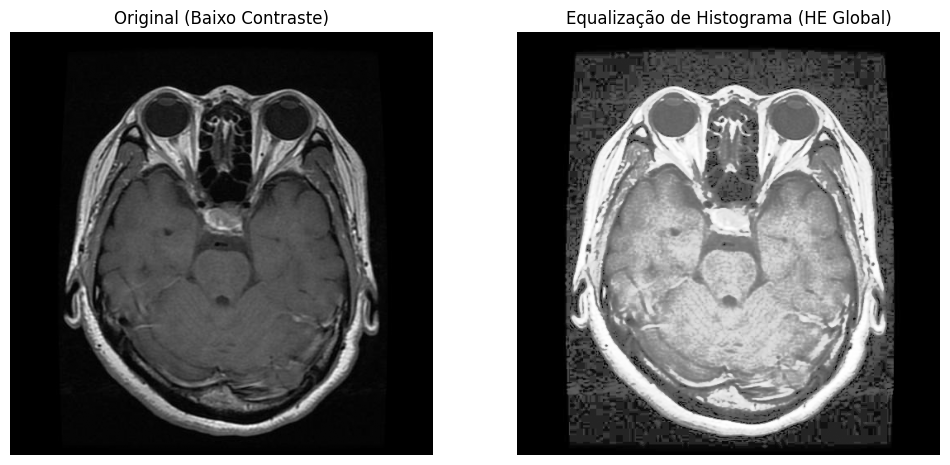

In [6]:
# --- 2. Carregamento da Imagem ---
caminho_da_imagem = "P_1.jpg"

# Lê a imagem em escala de cinza (equivalente ao EBImage)
img_baixo_contraste = cv2.imread(caminho_da_imagem, cv2.IMREAD_GRAYSCALE)

print("Iniciando Equalização de Histograma...")

# --- 3. Equalização de Histograma (HE Global) ---
# Equivalente ao equalize() do EBImage
img_equalizada = cv2.equalizeHist(img_baixo_contraste)

# --- 4. Exibição e Comparação ---
print("Exibindo e comparando o resultado...")

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_baixo_contraste, cmap='gray')
plt.title("Original (Baixo Contraste)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_equalizada, cmap='gray')
plt.title("Equalização de Histograma (HE Global)")
plt.axis("off")

plt.show()


## Equalização de Histograma Adaptativa (CLAHE)

Iniciando pré-processamento para CLAHE...
Dimensões Originais: 512x512
Dimensões Redimensionadas: 512x512
Iniciando Equalização Adaptativa (CLAHE)...
Exibindo as imagens...


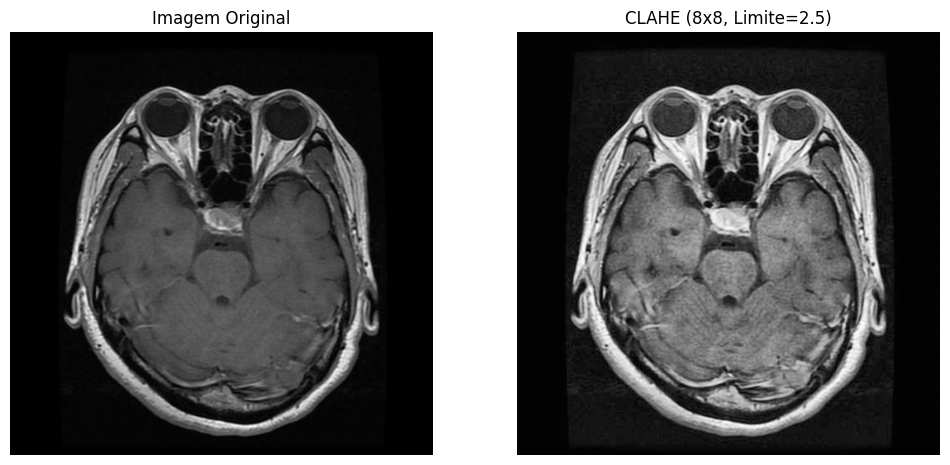

In [7]:
# --- 2. Parâmetros CLAHE ---
NUM_BLOCKS_X = 8
NUM_BLOCKS_Y = 8
CLIP_LIMIT = 2.5

# --- 3. Carregamento da Imagem ---
caminho_da_imagem = "P_1.jpg"
img_original = cv2.imread(caminho_da_imagem, cv2.IMREAD_GRAYSCALE)

print("Iniciando pré-processamento para CLAHE...")

# Dimensões originais
altura_original, largura_original = img_original.shape

# --- 3.1. Cálculo das novas dimensões (múltiplos exatos dos blocos) ---
nova_largura = largura_original - (largura_original % NUM_BLOCKS_X)
nova_altura = altura_original - (altura_original % NUM_BLOCKS_Y)

if nova_largura <= 0 or nova_altura <= 0:
    raise ValueError("Erro no cálculo do redimensionamento. A imagem é muito pequena.")

# --- 3.2. Redimensionamento da imagem ---
img_resized = cv2.resize(img_original, (nova_largura, nova_altura))

print(f"Dimensões Originais: {largura_original}x{altura_original}")
print(f"Dimensões Redimensionadas: {nova_largura}x{nova_altura}")
print("Iniciando Equalização Adaptativa (CLAHE)...")

# --- 4. Aplicação do CLAHE ---
# Em OpenCV, o CLAHE usa "tileGridSize" para o número de blocos (nx, ny)
clahe = cv2.createCLAHE(clipLimit=CLIP_LIMIT, tileGridSize=(NUM_BLOCKS_X, NUM_BLOCKS_Y))
img_clahe_final = clahe.apply(img_resized)

# --- 5. Exibição ---
print("Exibindo as imagens...")

plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(img_original, cmap='gray')
plt.title("Imagem Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_clahe_final, cmap='gray')
plt.title(f"CLAHE ({NUM_BLOCKS_X}x{NUM_BLOCKS_Y}, Limite={CLIP_LIMIT})")
plt.axis("off")

plt.show()